# Modeling Financial Loss 
Two models used: 
1. Linear regression 
2. Neural Network with MSE loss and standardized for training

Next steps: 
- Feature engineering: find and exclude near-constant or dependent features 
- Exclude input variables that wouldn't be known at time of prediction 
- Random Forest / XGBoost 

In [73]:
import pandas as pd
import numpy as np
import torch 
from torch import nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [74]:
data_directory = "../Data/unh_hackathon_prompt_2_data.json"
sys.path.append("../UNH-Hackathon-2026-Group-3/")

## preparing the data


In [75]:
def load_predictive_warfighting_data(file_path: str = "unh_hackathon_prompt_2_data.json") -> pd.DataFrame:
    """Load data from a CSV file into a pandas DataFrame."""
    return pd.read_json(file_path)

dirty_df = load_predictive_warfighting_data(data_directory)

# print data types of each column
# print(dirty_df.dtypes)

In [76]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the DataFrame by converting data types."""

    # Convert the string "NULL" to pd.NA
    df = df.replace("NULL", pd.NA)
    df = df.replace("N/A", pd.NA)

    for numeric_string_column in [
        "Enemy.Capability.Index",
        "EW_Capability",
        "Intel Confidence",

    ]:
        df[numeric_string_column] = pd.to_numeric(df[numeric_string_column])

    for boolean_string_column in [
        "response_success"
    ]:
        df[boolean_string_column] = df[boolean_string_column].map({"Yes": 1, "No": 0, "1": 1, "0": 0})

    return df

df = clean_data(dirty_df)

# get unique values for each string column, and min/max for each numeric column
for column in df.columns:
    if df.dtypes[column] == "str":
        print(f"Values: {df[column].drop_duplicates()}")
    else: 
        print(f"Name: {column}, dtype: {df.dtypes[column]}, min: {df[column].min()}, max: {df[column].max()}")

print(f"number of rows: {len(df)}")     
df.head()

Values: 0       Missile
2           Air
3         Cyber
4        Hybrid
7         Naval
14          AIR
35        CYBER
39       Hybrid
43          Msl
79        naval
119       Cyber
239         AIR
279         Air
299       naval
319     Missile
Name: Threat Type, dtype: str
Name: enemy_unit_count, dtype: int64, min: 1, max: 50
Name: Enemy.Capability.Index, dtype: int64, min: 1, max: 10
Name: ThreatEscalationHours, dtype: int64, min: 1, max: 72
Name: friendlyUnitCount, dtype: int64, min: 5, max: 60
Name: LCS_COUNT, dtype: int64, min: 0, max: 8
Name: Aircraft Count, dtype: int64, min: 0, max: 24
Name: cyber_defense_teams, dtype: int64, min: 0, max: 12
Name: Patriot.Batteries, dtype: int64, min: 0, max: 6
Name: ISR_AssetCount, dtype: int64, min: 0, max: 15
Name: satellite coverage score, dtype: float64, min: 0.2, max: 1.0
Name: JointForceIntegration, dtype: int64, min: 1, max: 10
Name: EW_Capability, dtype: float64, min: 0.0, max: 10.0
Name: Supply Chain Resilience, dtype: float64, min

,Threat Type,enemy_unit_count,Enemy.Capability.Index,ThreatEscalationHours,friendlyUnitCount,LCS_COUNT,Aircraft Count,cyber_defense_teams,Patriot.Batteries,ISR_AssetCount,...,CMD_COORD_SCORE,roe_complexity_score,Operational Budget (MUSD),BudgetUtilization_pct,Weather_Severity,Theater Distance KM,Season,response_success,Financial_Loss_MUSD,actual_days_to_stabilization
0,Missile,25,8,34,21,0,0,0,4,12,...,7,3,98,84,3,5164.8,Winter,1,388,10.1
1,Missile,3,2,8,45,0,0,0,4,4,...,9,5,189,97,1,7149.7,Fall,1,244,2.0
2,Air,7,3,48,45,0,5,0,0,14,...,9,1,92,88,0,6706.5,Winter,1,280,2.0
3,Cyber,31,7,70,57,0,0,7,0,5,...,10,3,314,86,9,1851.9,Fall,1,330,5.3
4,Hybrid,14,5,27,57,0,0,0,0,10,...,6,4,290,84,4,983.7,Spring,1,240,11.0


In [77]:
# get count of rows for each threat type 
threat_type_counts = df["Threat Type"].value_counts()
threat_type_counts

Threat Type
Naval       741
Air         684
Hybrid      557
Cyber       425
Missile     408
AIR          42
CYBER        32
Msl          21
 naval       19
 Hybrid      15
naval        15
 Cyber       13
 Missile     13
 Air         10
 AIR          5
Name: count, dtype: int64

In [78]:
# combine "Naval", "  naval", and "naval" into same category 
df["Threat Type"] = df["Threat Type"].str.strip()  # Remove leading/trailing whitespace
df["Threat Type"] = df["Threat Type"].str.lower()  # Convert to lowercase for consistency

# combine missile and msl into same threat type 
df["Threat Type"] = df["Threat Type"].replace({"msl": "missile"})

threat_type_counts = df["Threat Type"].value_counts()
threat_type_counts


Threat Type
naval      775
air        741
hybrid     572
cyber      470
missile    442
Name: count, dtype: int64

In [119]:
# filter by threat type here, before dropping nas 
df = df[df["Threat Type"] == "air"]

In [120]:
# remove rows with nan values in any column 
df = df.dropna()
len(df)

728

In [121]:
# get array of values for input variables:
''' 
every column except output/results and categorical variables 
- also remove columns with nan values 
'''
input_columns = df.select_dtypes(include=[np.number]).columns.tolist()
input_columns.remove('response_success')
input_columns.remove('Financial_Loss_MUSD')
input_columns.remove('actual_days_to_stabilization')
input_columns.remove('CMD_COORD_SCORE')
input_columns = [col for col in input_columns if not df[col].isna().any()]
inputs = df[input_columns].values


# get array of values for output variables:
'''
response_success, dtype: int64
Financial_Loss_MUSD, dtype: int64
actual_days_to_stabilization, dtype: float64
'''
response_successes = df['response_success'].values
financial_loss_musds = df['Financial_Loss_MUSD'].values
actual_days_to_stabilizations = df['actual_days_to_stabilization'].values

output = financial_loss_musds

# list all input columns 
print(input_columns)

['enemy_unit_count', 'Enemy.Capability.Index', 'ThreatEscalationHours', 'friendlyUnitCount', 'LCS_COUNT', 'Aircraft Count', 'cyber_defense_teams', 'Patriot.Batteries', 'ISR_AssetCount', 'satellite coverage score', 'JointForceIntegration', 'EW_Capability', 'Supply Chain Resilience', 'PriorEngagements', 'force_readiness_score', 'Intel Confidence', 'ResponseTime_hrs', 'logistics_delay_hours', 'roe_complexity_score', 'Operational Budget (MUSD)', 'BudgetUtilization_pct', 'Weather_Severity', 'Theater Distance KM']


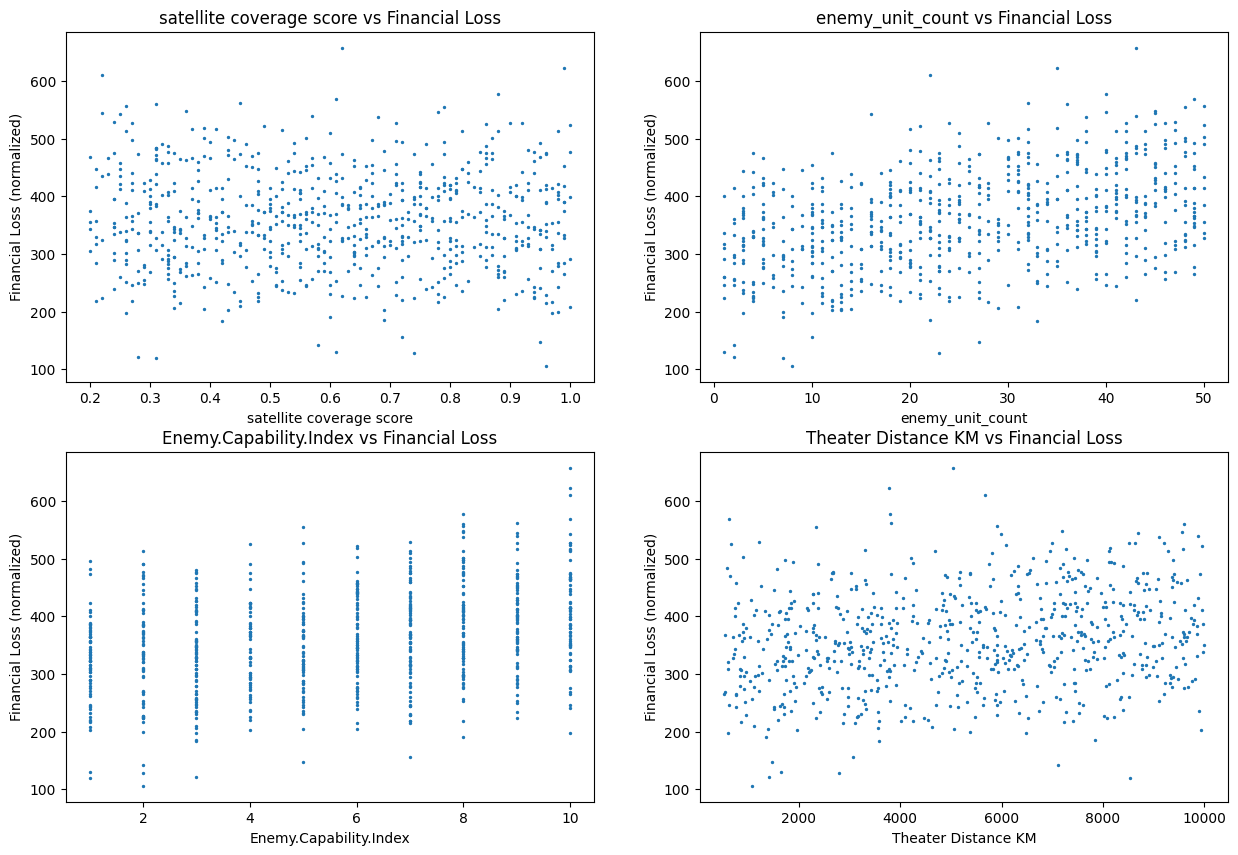

In [122]:
# plot input vs output for some input variables
input_names = [
    'satellite coverage score',
    'enemy_unit_count',
    'Enemy.Capability.Index',
    'Theater Distance KM'
]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.scatter(df[input_names[i]], output, s=2)
    ax.set_xlabel(input_names[i])
    ax.set_ylabel("Financial Loss (normalized)")
    ax.set_title(f"{input_names[i]} vs Financial Loss")


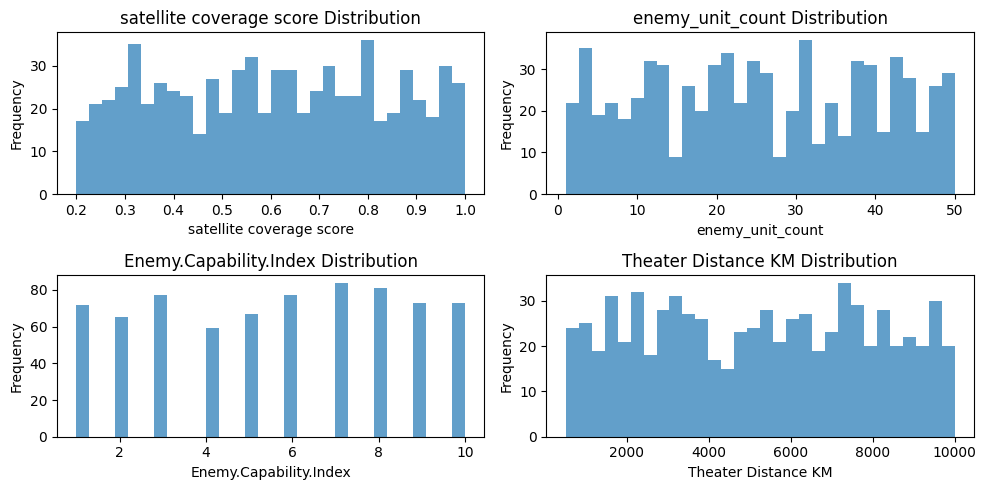

In [123]:
# histogram for some input variables
input_names = [
    'satellite coverage score',
    'enemy_unit_count',
    'Enemy.Capability.Index',
    'Theater Distance KM'
]
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.hist(df[input_names[i]], bins=30, alpha=0.7)
    ax.set_xlabel(input_names[i])
    ax.set_ylabel("Frequency")
    ax.set_title(f"{input_names[i]} Distribution")

plt.tight_layout()
plt.show()

## preparing + running the model to predict financial loss

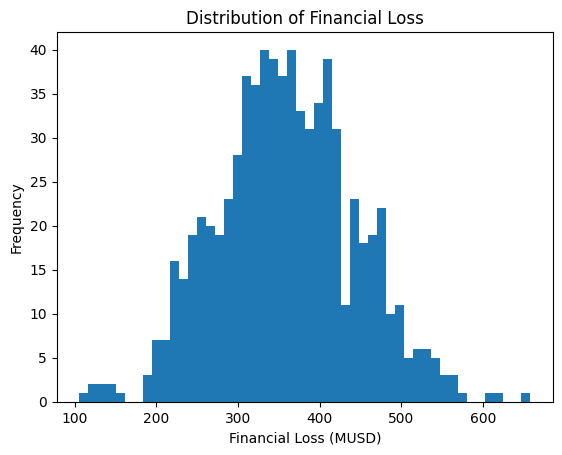

In [124]:
# visualize the distribution 
plt.hist(financial_loss_musds, bins=50)
plt.xlabel("Financial Loss (MUSD)")
plt.ylabel("Frequency")
plt.title("Distribution of Financial Loss")
plt.show()

In [125]:
# scikit learn train test split implementation 
inputs_train, inputs_test, output_train, output_test = train_test_split(
    inputs, output, test_size=0.2, random_state=42)

inputs_train[0], output_train[0]

(array([1.8000e+01, 6.0000e+00, 6.6000e+01, 1.6000e+01, 0.0000e+00,
        2.3000e+01, 0.0000e+00, 0.0000e+00, 2.0000e+00, 5.5000e-01,
        8.0000e+00, 5.0000e+00, 5.0000e-01, 2.4000e+01, 8.4000e+01,
        4.5000e-01, 2.5000e+01, 1.3000e+01, 2.0000e+00, 1.1700e+02,
        6.7000e+01, 1.0000e+00, 5.8309e+03]),
 np.int64(406))

In [126]:
# standardize 
train_input_means = np.mean(inputs_train, axis=0)
train_input_stds = np.std(inputs_train, axis=0)
inputs_train = (inputs_train - train_input_means) / (train_input_stds + 1e-8)
inputs_test = (inputs_test - train_input_means) / (train_input_stds + 1e-8)

train_output_mean = np.mean(output_train)
train_output_std = np.std(output_train)
output_train = (output_train - train_output_mean) / (train_output_std + 1e-8)
output_test = (output_test - train_output_mean) / (train_output_std + 1e-8)

inputs_train[0], output_train[0]

(array([-0.53875855,  0.124941  ,  1.50695558, -1.10160102,  0.        ,
         1.53770893,  0.        ,  0.        , -1.16300362, -0.2108278 ,
         0.8692699 ,  0.01807208, -1.08256003,  1.54707879,  0.77308686,
        -1.01945736,  0.05743779,  0.14460179, -0.65590713, -1.24722053,
        -1.16123086, -1.24701225,  0.19569796]),
 np.float64(0.5477056578981591))

# linear regression

In [127]:
torch.Tensor(inputs_train)[0]

tensor([-0.5388,  0.1249,  1.5070, -1.1016,  0.0000,  1.5377,  0.0000,  0.0000,
        -1.1630, -0.2108,  0.8693,  0.0181, -1.0826,  1.5471,  0.7731, -1.0195,
         0.0574,  0.1446, -0.6559, -1.2472, -1.1612, -1.2470,  0.1957])

In [128]:
# linear regression model 
class LinearRegressionModel(torch.nn.Module):

    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(len(inputs[0]), 1)  # One in and one out

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred
    
linearmodel = LinearRegressionModel()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(linearmodel.parameters(), lr=0.01)

for epoch in range(500):

    # Forward pass: Compute predicted y by passing 
    # x to the model
    pred_y = linearmodel(torch.Tensor(inputs_train))

    # Compute and print loss
    loss = criterion(pred_y, torch.Tensor(output_train))

    # Zero gradients, perform a backward pass, 
    # and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('epoch {}, loss {}'.format(epoch, loss.item()))

/Users/katherinesong/UNH-Hackathon-2026-Group-3/.venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([582])) that is different to the input size (torch.Size([582, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 0, loss 1.241040825843811
epoch 1, loss 1.2322816848754883
epoch 2, loss 1.2238492965698242
epoch 3, loss 1.215730905532837
epoch 4, loss 1.2079147100448608
epoch 5, loss 1.2003891468048096
epoch 6, loss 1.1931428909301758
epoch 7, loss 1.1861655712127686
epoch 8, loss 1.1794469356536865
epoch 9, loss 1.1729769706726074
epoch 10, loss 1.1667462587356567
epoch 11, loss 1.1607458591461182
epoch 12, loss 1.1549668312072754
epoch 13, loss 1.149401068687439
epoch 14, loss 1.1440403461456299
epoch 15, loss 1.1388767957687378
epoch 16, loss 1.1339030265808105
epoch 17, loss 1.129111886024475
epoch 18, loss 1.1244966983795166
epoch 19, loss 1.1200506687164307
epoch 20, loss 1.1157673597335815
epoch 21, loss 1.1116408109664917
epoch 22, loss 1.107664942741394
epoch 23, loss 1.1038341522216797
epoch 24, loss 1.100143313407898
epoch 25, loss 1.0965867042541504
epoch 26, loss 1.0931596755981445
epoch 27, loss 1.0898573398590088
epoch 28, loss 1.0866749286651611
epoch 29, loss 1.0836077928543

In [129]:
# get test metrics for linear regression model
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
def calculate_metrics(true_values, predictions):
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))

    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mape = np.mean(np.abs((true_values - predictions) / true_values)) * 100

    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
    print(f"R² Score: {r2:.6f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")  
    return mae, r2, rmse, mape

true_values = output_test 
predictions = linearmodel(torch.Tensor(inputs_test)).detach().numpy().flatten()
calculate_metrics(true_values, predictions)

Mean Absolute Error (MAE): 0.728301
Root Mean Squared Error (RMSE): 0.894853
R² Score: -0.001398
Mean Absolute Percentage Error (MAPE): 99.99%


(0.7283014637609186,
 -0.001397876203847126,
 np.float64(0.8948531971397555),
 np.float64(99.98812988760852))

## ElasticNetCV

In [130]:
from sklearn.linear_model import ElasticNetCV
from sklearn.datasets import make_regression
X = inputs_train
y = output_train
regr = ElasticNetCV(cv=5, random_state=0)
regr.fit(X, y)
print(regr.alpha_)
print(regr.intercept_)
print(regr.predict([[0]*len(input_columns)]))

true_values = output_test
predictions = regr.predict(inputs_test)
calculate_metrics(true_values, predictions)

0.004454955310356144
-4.908847724323769e-16
[-4.90884772e-16]
Mean Absolute Error (MAE): 0.190377
Root Mean Squared Error (RMSE): 0.298783
R² Score: 0.888361
Mean Absolute Percentage Error (MAPE): 78.07%


(0.19037704751234033,
 0.8883610881519834,
 np.float64(0.29878325790165466),
 np.float64(78.07163804448672))

# torch.nn 

In [131]:
class NNmodel(nn.Module):
    def __init__ (self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(len(inputs_train[0]), 64),
            nn.BatchNorm1d(64), 
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)

        )

    def forward(self, x):
        # logits = self.linear_relu_stack(x)
        return self.linear_relu_stack(x)
    
class AbsDataset(Dataset):
    def __init__ (self, inputs, output):
        self.input_tensor = torch.tensor(inputs).float() 
        self.output_tensor = torch.tensor(output).float()
        
    def __len__(self):
        return len(self.output_tensor)
    
    def __getitem__(self, idx):
        return self.input_tensor[idx], self.output_tensor[idx] 

In [132]:
train_dataset = AbsDataset(inputs_train, output_train)
test_dataset = AbsDataset(inputs_test, output_test)

# shuffles and batches 
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# initiate model
nnmodel = NNmodel()
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(nnmodel.parameters(), lr=0.0007) # learning rate


In [133]:
# training with per-epoch testing
training_loss_ls = []
test_loss_ls = []

epochs = 50

for epoch in range(epochs):
    epoch_loss_ls = []
    print("epoch #:", epoch)

    # training loop 
    nnmodel.train()
    for data, labels in train_loader:
        optimizer.zero_grad() # resets gradients in optimizer to 0 
        outputs = nnmodel(data)

        # calculate loss function (MSE)
        loss = loss_func(outputs, labels.unsqueeze(1))
        epoch_loss_ls.append(loss.item())
        loss.backward() # back prop 

        # optimizer 
        optimizer.step() # updates all parameters via gradient descent 
        
    avg_loss = np.average(np.array(epoch_loss_ls))
    print("average training loss:", avg_loss)
    training_loss_ls.append(avg_loss)
    
    # testing loop per epoch
    nnmodel.eval()
    test_epoch_ls = []
    with torch.no_grad():
        for data, labels in test_loader:
            outputs = nnmodel(data)
            loss = loss_func(outputs, labels)
            test_epoch_ls.append(loss.item())
    
    avg_test_loss = np.average(np.array(test_epoch_ls))
    print("average test loss:", avg_test_loss)
    test_loss_ls.append(avg_test_loss)

epoch #: 0
average training loss: 1.1342063903808595
average test loss: 0.8114101639850984
epoch #: 1
average training loss: 0.854558789730072
average test loss: 0.6823012555444259
epoch #: 2
average training loss: 0.5918000906705856
average test loss: 0.4841526329465735
epoch #: 3
average training loss: 0.43126317411661147
average test loss: 0.30343256119452494
epoch #: 4
average training loss: 0.2954685740172863
average test loss: 0.21583965080985576
epoch #: 5
average training loss: 0.2781655803322792
average test loss: 0.20146233574922456
epoch #: 6
average training loss: 0.19273122400045395


/Users/katherinesong/UNH-Hackathon-2026-Group-3/.venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


average test loss: 0.1917303094769064
epoch #: 7
average training loss: 0.1981874167919159
average test loss: 0.18572920333895437
epoch #: 8
average training loss: 0.15246803686022758
average test loss: 0.16993555189563342
epoch #: 9
average training loss: 0.1694512441754341
average test loss: 0.16525410062287896
epoch #: 10
average training loss: 0.17504724562168122
average test loss: 0.17359559488637694
epoch #: 11
average training loss: 0.15102505981922149
average test loss: 0.1604344812368341
epoch #: 12
average training loss: 0.20788759216666222
average test loss: 0.15589898033842212
epoch #: 13
average training loss: 0.27144198790192603
average test loss: 0.1357615514782444
epoch #: 14
average training loss: 0.12769918218255044
average test loss: 0.15087050427513382
epoch #: 15
average training loss: 0.1638152666389942
average test loss: 0.1444786531534528
epoch #: 16
average training loss: 0.19186853393912315
average test loss: 0.15009256978113975
epoch #: 17
average training lo

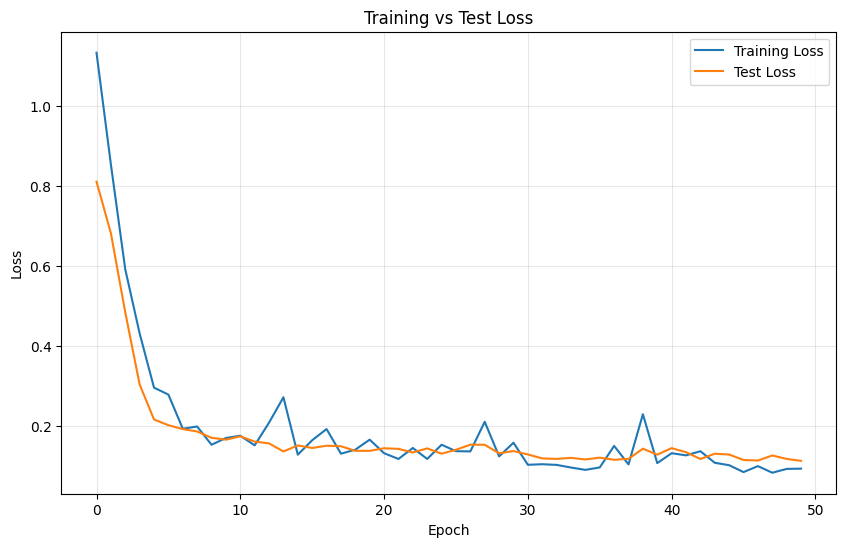

In [134]:
# Plot training and test loss together
x = range(epochs)
plt.figure(figsize=(10, 6))
plt.plot(x, training_loss_ls, label='Training Loss')
plt.plot(x, test_loss_ls, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Test Loss')
plt.grid(True, alpha=0.3)
plt.show()

## visualizing the model 

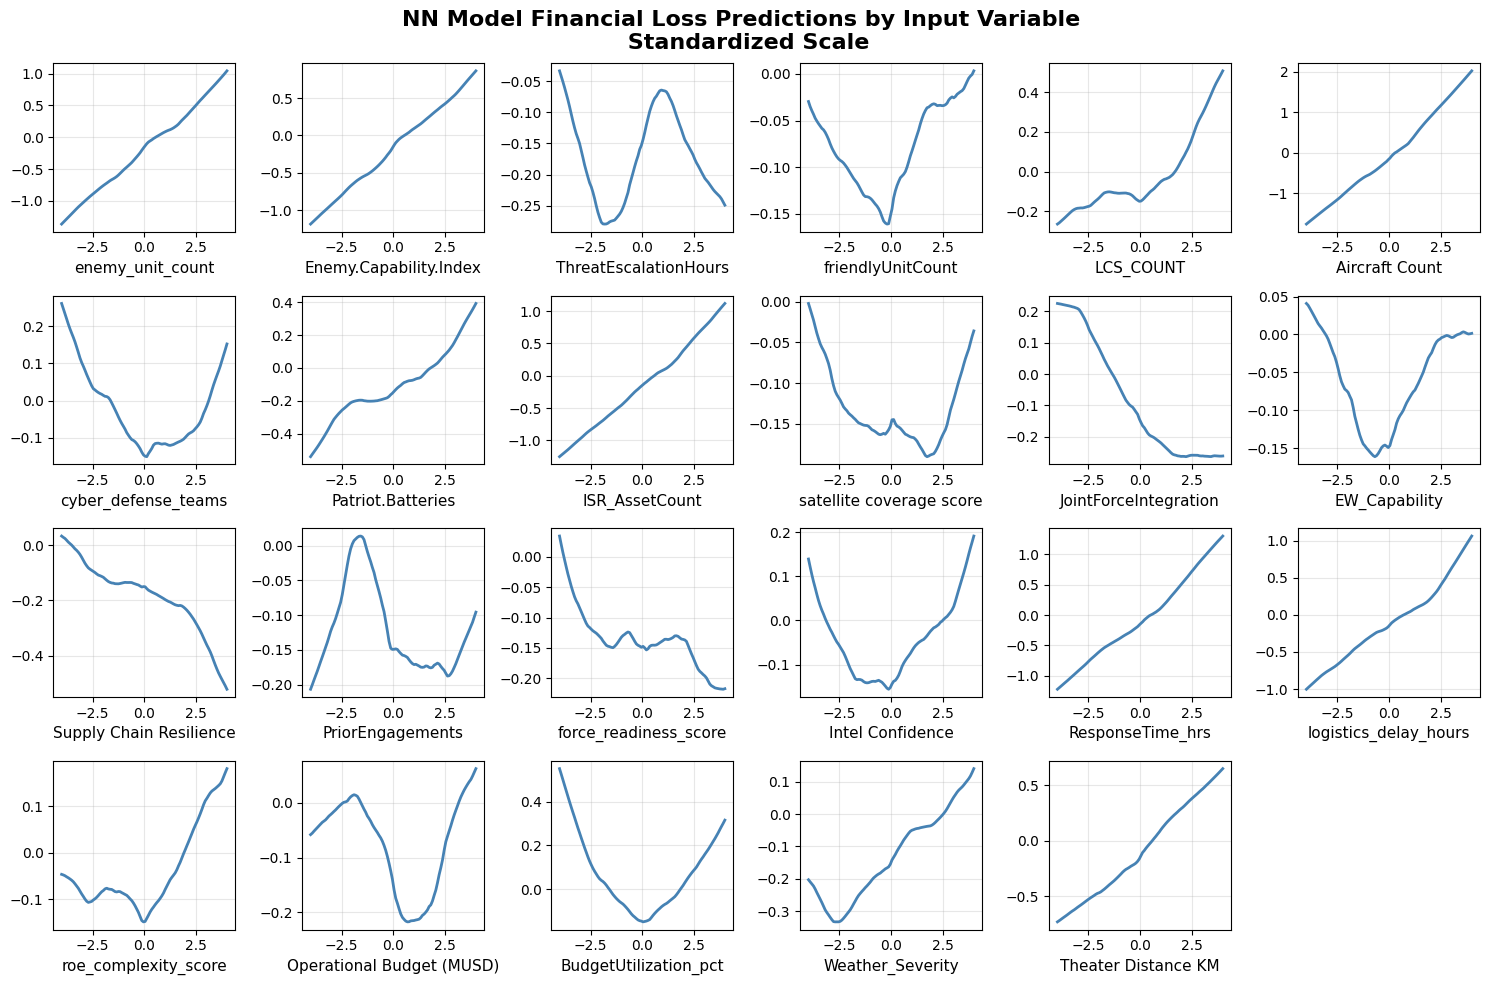

In [135]:
# Visualize nn model: 2D plots of each input vs output
nnmodel.eval() # Set model to evaluation mode

fig, axes = plt.subplots(4, 6, figsize=(15, 10))
axes = axes.flatten()

# For each input variable, create predictions while varying that input
for i, ax in enumerate(axes):
    if i > len(input_columns) - 1:
        ax.axis('off')  # Hide unused subplots
        continue
    
    # Create a range of values for the input variable
    input_range = np.linspace(-4, 4, 100)
    
    # Create prediction arrays by holding other inputs at their mean
    predictions = []
    
    for val in input_range:
        # Start with mean normalized values for all inputs
        input_vector = np.mean(inputs_train, axis=0) # should be around zero 
        
        # Vary the current input
        input_vector[i] = val
        
        # Convert to tensor and predict
        input_tensor = torch.tensor(input_vector).float().unsqueeze(0)
        with torch.no_grad():
            pred = nnmodel(input_tensor).item()
        predictions.append(pred)
    
    # Plot
    ax.plot(input_range, predictions, linewidth=2, color='steelblue')
    ax.set_xlabel(input_columns[i], fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('NN Model Financial Loss Predictions by Input Variable \n Standardized Scale', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

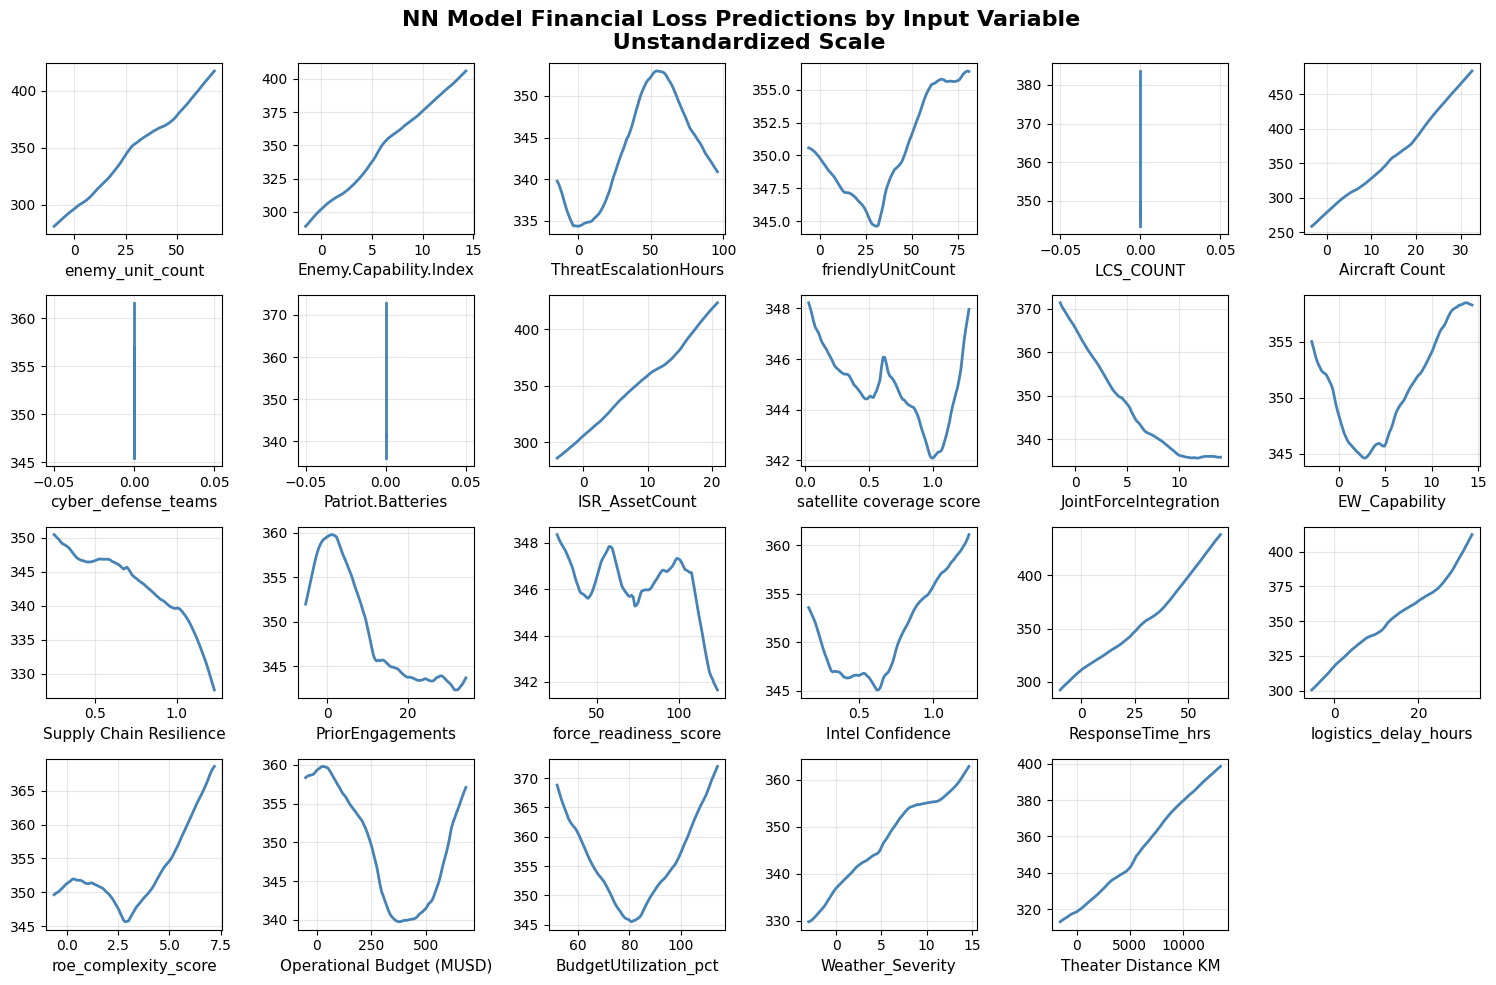

In [136]:
# plots of unstandardized predictions vs unstandardized inputs 
nnmodel.eval()
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
axes = axes.flatten()

# For each input variable, create predictions while varying that input
for i, ax in enumerate(axes):
    if i > len(input_columns) - 1:
        ax.axis('off')  # Hide unused subplots
        continue
    
    # Create a range of values for the input variable
    input_range = np.linspace(-2.5, 3, 100)
    
    # Create prediction arrays by holding other inputs at their mean
    predictions = []
    
    for val in input_range:
        # Start with mean normalized values for all inputs
        input_vector = np.mean(inputs_train, axis=0) # should be around zero 
        
        # Vary the current input
        input_vector[i] = val
        
        # Convert to tensor and predict
        input_tensor = torch.tensor(input_vector).float().unsqueeze(0)
        with torch.no_grad():
            pred = nnmodel(input_tensor).item()
        predictions.append(pred)

    # unstandardize 
    input_range = input_range * train_input_stds[i] + train_input_means[i]
    predictions = np.array(predictions) * train_output_std + train_output_mean

    # Plot
    ax.plot(input_range, predictions, linewidth=2, color='steelblue')
    ax.set_xlabel(input_columns[i], fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('NN Model Financial Loss Predictions by Input Variable \n Unstandardized Scale', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


    

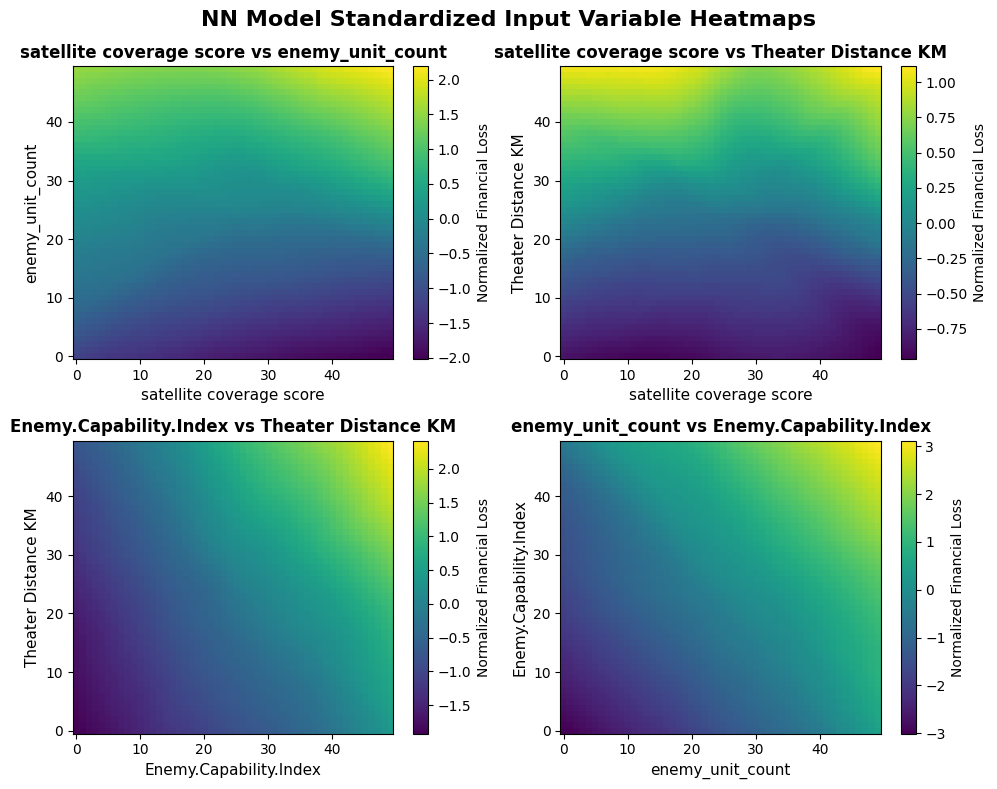

In [137]:
# Create 2D heatmaps for key input pairs
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

input_names = [
    'satellite coverage score',
    'enemy_unit_count',
    'Enemy.Capability.Index',
    'Theater Distance KM'
]

# Define pairs to visualize (most important interactions)
pairs = [(0, 1), (0, 3), (2, 3), (1, 2)]

for plot_idx, (i, j) in enumerate(pairs):
    ax = axes[plot_idx]
    
    # Create grid of values
    input_range = np.linspace(-5, 5, 50)
    heatmap = np.zeros((len(input_range), len(input_range)))
    
    # Fill heatmap by varying inputs i and j
    for x_idx, x_val in enumerate(input_range):
        for y_idx, y_val in enumerate(input_range):
            input_vector = np.mean(inputs_train, axis=0)
            input_vector[input_columns.index(input_names[i])] = x_val
            input_vector[input_columns.index(input_names[j])] = y_val
            
            input_tensor = torch.tensor(input_vector).float().unsqueeze(0)
            with torch.no_grad():
                pred = nnmodel(input_tensor).item()
            heatmap[y_idx, x_idx] = pred
    
    # Plot heatmap with color scale
    im = ax.imshow(heatmap, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xlabel(input_names[i], fontsize=11)
    ax.set_ylabel(input_names[j], fontsize=11)
    ax.set_title(f'{input_names[i]} vs {input_names[j]}', fontsize=12, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized Financial Loss')

plt.suptitle('NN Model Standardized Input Variable Heatmaps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [138]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
def calculate_metrics(true_values, predictions):
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))

    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)
    rmse = np.sqrt(mean_squared_error(true_values, predictions))
    mape = np.mean(np.abs((true_values - predictions) / true_values)) * 100

    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
    print(f"R² Score: {r2:.6f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")  
    return mae, r2, rmse, mape

In [139]:
nnmodel.eval()

predictions = []
true_values = []

# calculate mean square error on train dataset 
with torch.no_grad():
    for data, labels in DataLoader(test_dataset, batch_size=32):
        outputs = nnmodel(data)
        predictions.extend(outputs.numpy().flatten())
        true_values.extend(labels.numpy().flatten())

predictions = np.array(predictions)
true_values = np.array(true_values)

# Calculate metrics
calculate_metrics(true_values, predictions) 


Mean Absolute Error (MAE): 0.226631
Root Mean Squared Error (RMSE): 0.335012
R² Score: 0.859646
Mean Absolute Percentage Error (MAPE): 104.52%


(0.2266305834054947,
 0.8596460819244385,
 np.float64(0.33501225959706865),
 np.float32(104.51944))

This isn't much better than the ElasticNetCV implementation, improved by ~0.01 in both MAE (0.23 -> 0.22) and RMSE (0.33 -> 0.32). MAPE increased about 3%...

In [140]:
# calculate metrics on original (unstandardized) scale
predictions_unstd = predictions * (train_output_std) + train_output_mean
true_values_unstd = true_values * (train_output_std) + train_output_mean

# Calculate metrics
calculate_metrics(true_values_unstd, predictions_unstd)

Mean Absolute Error (MAE): 19.625483
Root Mean Squared Error (RMSE): 29.010987
R² Score: 0.859646
Mean Absolute Percentage Error (MAPE): 5.50%


(19.62548323777479,
 0.8596461022746631,
 np.float64(29.010987162981525),
 np.float64(5.500314161930174))

## 